In [ ]:
import numpy as np
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm
import zarr
import re
import plot_utils as pu

In [2]:
pu.apply_plot_style()

In [3]:
SHARD_RE = re.compile(r"^shard_\d{5}_\d{5}\.zarr$")

def load_episode(root_dir: str | Path, episode_id: int) -> dict:
    """Load one trajectory from a sharded Zarr dataset by episode ID."""

    root_dir = Path(root_dir)
    group_name = f"trj_{episode_id:06d}"

    for shard_path in sorted(root_dir.iterdir()):
        if not shard_path.is_dir() or not SHARD_RE.match(shard_path.name):
            continue

        shard = zarr.open_group(str(shard_path), mode="r")

        if group_name not in shard:
            continue

        group = shard[group_name]

        dense_state = {
            int(name.rsplit("_", 1)[-1]): group[name][:]
            for name in group.array_keys()
            if name.startswith("dense_state_")
        }

        return {
            "observations": group["observations"][:],
            "actions": group["actions"][:],
            "rewards": group["rewards"][:],
            "dense_time": group["dense_time"][:],
            "equilibrium_radii": group["equilibrium_radii"][:],
            "dense_state": dense_state,
            "attrs": dict(group.attrs),
        }

    raise KeyError(f"Episode {episode_id} not found in {root_dir}")

In [4]:
DATA_ROOT = (Path(__vsc_ipynb_file__).parents[2] / "trj")


# 2 Bubble Control

In [124]:
TRIAL        = "PA_PS_Control_b2_epb32_ne2048_id1778346737"
DATA_4B      = DATA_ROOT / "2B_DistanceControl"
TRAJECTORIES = DATA_4B / TRIAL

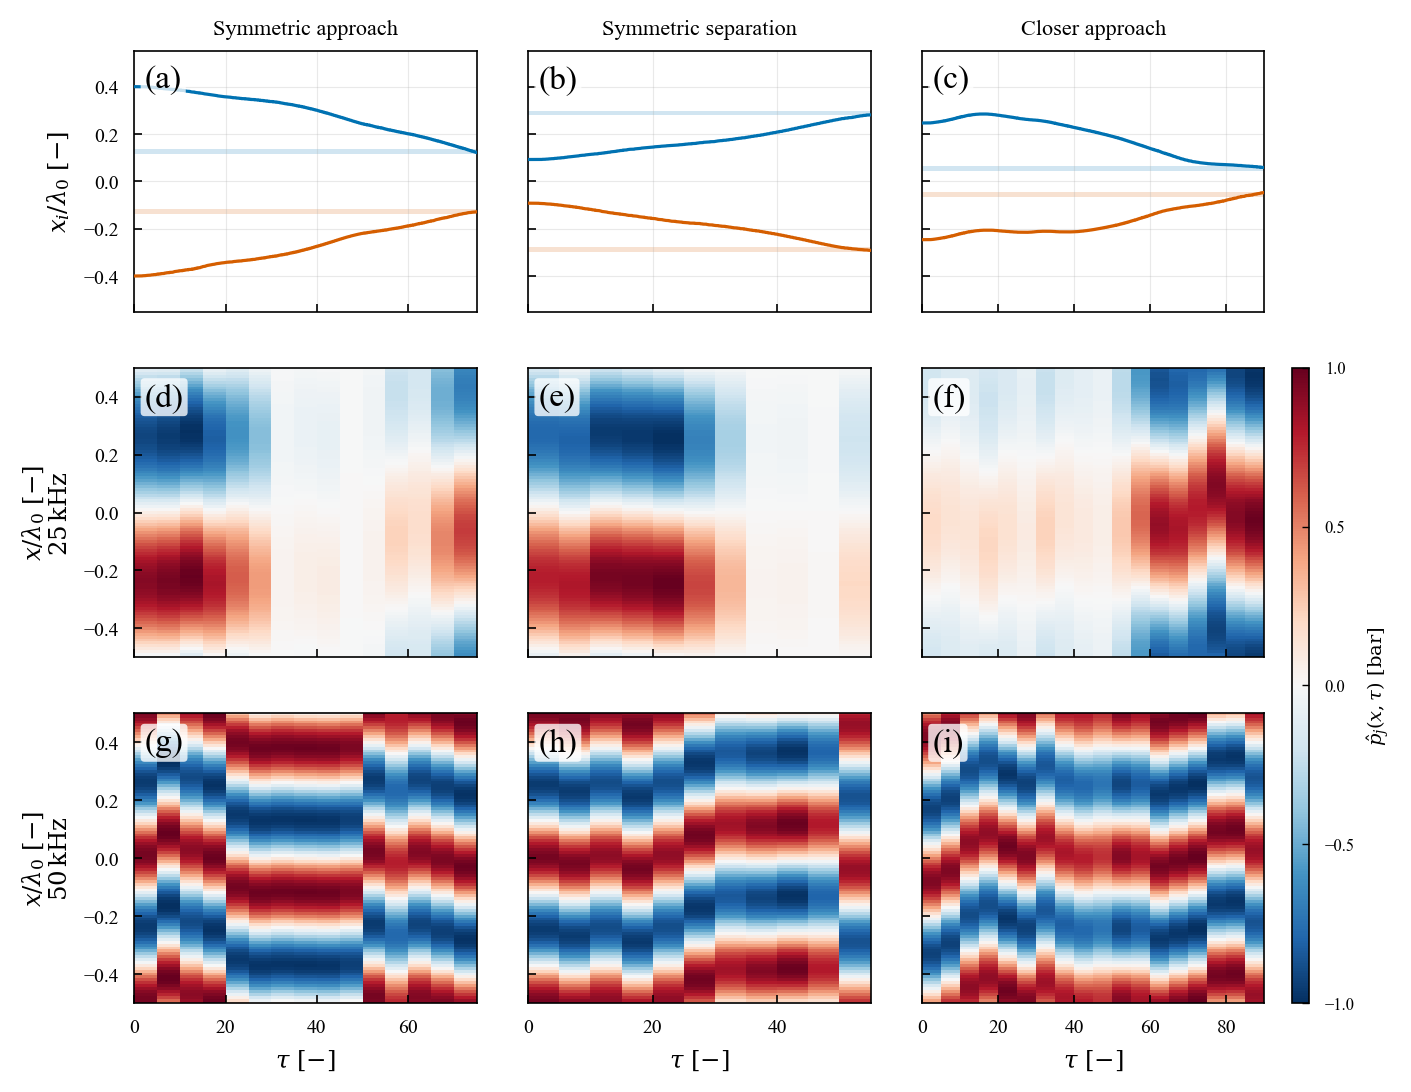

In [127]:
EPISODES = [2000, 1006, 2023]
UPS = 2
TOL = 1e-2

ACTION_DT = 5.0
PLOT_RES = 101
FIELD_VMAX = 1.0

xgrid = np.linspace(-0.5, 0.5, PLOT_RES)

dx = xgrid[1] - xgrid[0]
x_edges = np.r_[
    xgrid[0] - 0.5 * dx,
    0.5 * (xgrid[:-1] + xgrid[1:]),
    xgrid[-1] + 0.5 * dx,
]

field_norm = TwoSlopeNorm(vmin=-FIELD_VMAX, vcenter=0.0, vmax=FIELD_VMAX)

nrows, ncols = 3, len(EPISODES)

(fig_w, fig_h), adj = pu.two_column_figsize(
    nrows, ncols,
    width_in=7.0,
    panel_height_in=1.40,
    wspace=0.15,
    hspace=0.20,
)

# Hely a jobb oldali colorbarnak
adj["right"] = 0.90

with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        gridspec_kw={"height_ratios": [0.9, 1.0, 1.0]},
    )

    for j, episode in enumerate(EPISODES):
        trj = load_episode(TRAJECTORIES, episode)

        dense_time = np.asarray(trj["dense_time"])
        dense_state = trj["dense_state"]
        actions = np.asarray(trj["actions"])

        x = np.asarray(dense_state[1])
        target = np.asarray(trj["observations"][0, :UPS]) * 0.5

        # =========================================================
        # Top row: trajectories and target intervals
        # =========================================================

        for unit_id in range(UPS):
            color = pu.COLORS[unit_id]

            axes[0, j].axhspan(
                target[unit_id] - TOL,
                target[unit_id] + TOL,
                color=color,
                alpha=0.18,
                linewidth=0,
                zorder=0,
            )

            axes[0, j].plot(
                dense_time,
                x[:, unit_id],
                color=color,
                **pu.GPU_STYLE,
            )

        axes[0, j].set_ylim(-0.55, 0.55)
        axes[0, j].grid(True, which="major", linewidth=0.4, alpha=0.28, zorder=0)

        if j == 0:
            axes[0, j].set_ylabel(r"$x_i/\lambda_0\ [-]$")

        # =========================================================
        # Piecewise-constant action intervals
        # actions = [PA_0, PA_1, PS_0, PS_1]
        # =========================================================

        episode_duration = dense_time[-1] - dense_time[0]
        n_actions = min(len(actions), int(np.ceil(episode_duration / ACTION_DT)))
        actions = actions[:n_actions]

        action_edges = dense_time[0] + ACTION_DT * np.arange(n_actions + 1)
        action_edges[-1] = min(action_edges[-1], dense_time[-1])

        pa0 = actions[:, 0]
        pa1 = actions[:, 1]
        ps0 = actions[:, 2] * np.pi
        ps1 = actions[:, 3] * np.pi

        # =========================================================
        # Middle row: signed 25 kHz spatial amplitude
        # =========================================================

        field_0 = pa0[None, :] * np.sin(
            2.0 * np.pi * xgrid[:, None] + ps0[None, :]
        )

        axes[1, j].pcolormesh(
            action_edges,
            x_edges,
            field_0,
            shading="flat",
            cmap="RdBu_r",
            norm=field_norm,
            rasterized=True,
        )

        axes[1, j].set_ylim(-0.5, 0.5)

        if j == 0:
            axes[1, j].set_ylabel(
                r"$x/\lambda_0\ [-]$" "\n"
                r"$25\,\mathrm{kHz}$"
            )

        # =========================================================
        # Bottom row: signed 50 kHz spatial amplitude
        # =========================================================

        field_1 = pa1[None, :] * np.sin(
            4.0 * np.pi * xgrid[:, None] + ps1[None, :]
        )

        mesh = axes[2, j].pcolormesh(
            action_edges,
            x_edges,
            field_1,
            shading="flat",
            cmap="RdBu_r",
            norm=field_norm,
            rasterized=True,
        )

        axes[2, j].set_ylim(-0.5, 0.5)
        axes[2, j].set_xlim(dense_time[0], dense_time[-1])
        axes[2, j].set_xlabel(r"$\tau\ [-]$")

        if j == 0:
            axes[2, j].set_ylabel(
                r"$x/\lambda_0\ [-]$" "\n"
                r"$50\,\mathrm{kHz}$"
            )

        # =========================================================
        # Common axis formatting and panel labels
        # =========================================================

        for i in range(nrows):
            ax = axes[i, j]

            ax.tick_params(
                axis="both",
                which="major",
                direction="in",
                length=3,
                width=0.6,
                labelsize=7,
            )

            panel_label = chr(97 + i * ncols + j)

            ax.text(
                0.03,
                0.95,
                f"({panel_label})",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=12,
                bbox=dict(
                    boxstyle="round,pad=0.12",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.78,
                ),
                zorder=5,
            )

        column_titles = [
            "Symmetric approach",
            "Symmetric separation",
            "Closer approach",
        ]

        for j, title in enumerate(column_titles):
            axes[0, j].set_title(title, fontsize=8, pad=6)

    fig.subplots_adjust(**adj)

    # =============================================================
    # Shared vertical colorbar for both acoustic components
    # =============================================================

    cbar_bottom = axes[2, 0].get_position().y0
    cbar_top = axes[1, 0].get_position().y1

    cax = fig.add_axes([0.92, cbar_bottom, 0.012, cbar_top - cbar_bottom])  # type: ignore
    cbar = fig.colorbar(mesh, cax=cax, orientation="vertical", ticks=[-1.0, -0.5, 0.0, 0.5, 1.0])

    cbar.set_label(r"$\hat{p}_j(x,\tau)\ [\mathrm{bar}]$", fontsize=7, labelpad=4)
    cbar.ax.tick_params(direction="in", length=2.5, width=0.5, labelsize=6)

fig.savefig("figs/bubble_2_control.pdf", bbox_inches="tight")
fig.savefig("figs/bubble_2_control.png", dpi=300, bbox_inches="tight")
plt.show()

# 3Bubble Control

In [118]:
TRIAL        = "PA_PS_Control_b3_epb32_ne2048_id1783926598"
DATA_4B      = DATA_ROOT / "3B_DistanceControl"
TRAJECTORIES = DATA_4B / TRIAL

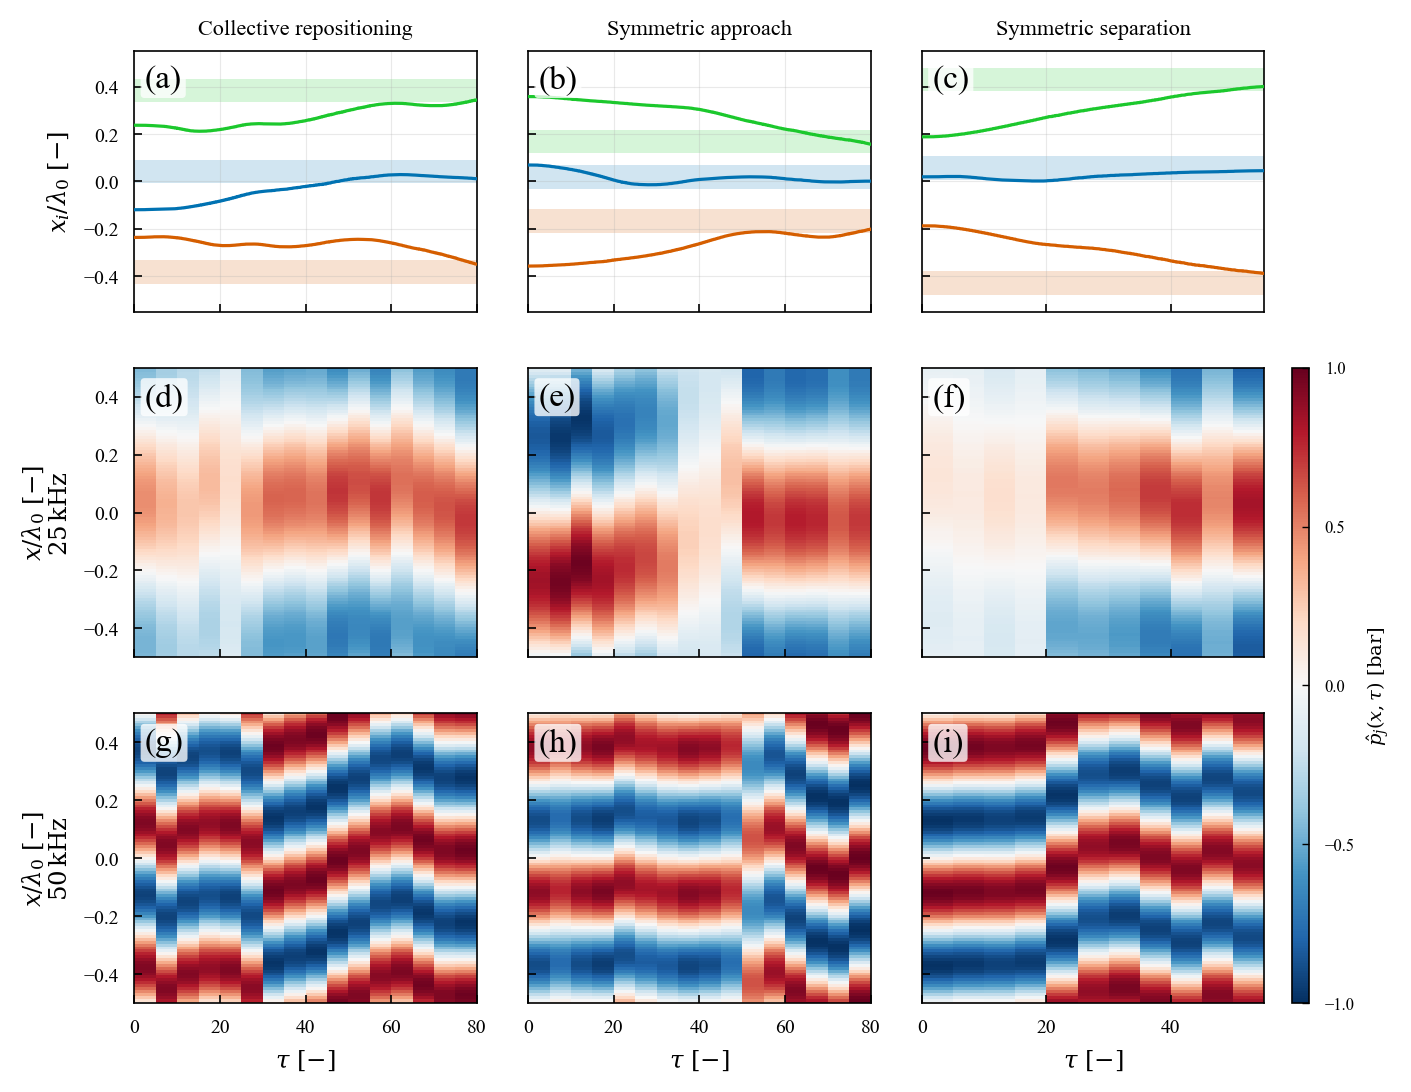

In [119]:
EPISODES = [5019, 6014, 5041]
UPS = 3
TOL = 5e-2

ACTION_DT = 5.0
PLOT_RES = 101
FIELD_VMAX = 1.0

xgrid = np.linspace(-0.5, 0.5, PLOT_RES)

dx = xgrid[1] - xgrid[0]
x_edges = np.r_[
    xgrid[0] - 0.5 * dx,
    0.5 * (xgrid[:-1] + xgrid[1:]),
    xgrid[-1] + 0.5 * dx,
]

field_norm = TwoSlopeNorm(vmin=-FIELD_VMAX, vcenter=0.0, vmax=FIELD_VMAX)

nrows, ncols = 3, len(EPISODES)

(fig_w, fig_h), adj = pu.two_column_figsize(
    nrows, ncols,
    width_in=7.0,
    panel_height_in=1.40,
    wspace=0.15,
    hspace=0.20,
)

# Hely a jobb oldali colorbarnak
adj["right"] = 0.90

with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        gridspec_kw={"height_ratios": [0.9, 1.0, 1.0]},
    )

    for j, episode in enumerate(EPISODES):
        trj = load_episode(TRAJECTORIES, episode)

        dense_time = np.asarray(trj["dense_time"])
        dense_state = trj["dense_state"]
        actions = np.asarray(trj["actions"])

        x = np.asarray(dense_state[1])
        target = np.asarray(trj["observations"][0, :UPS]) * 0.5

        # =========================================================
        # Top row: trajectories and target intervals
        # =========================================================

        for unit_id in range(UPS):
            color = pu.COLORS[unit_id]

            axes[0, j].axhspan(
                target[unit_id] - TOL,
                target[unit_id] + TOL,
                color=color,
                alpha=0.18,
                linewidth=0,
                zorder=0,
            )

            axes[0, j].plot(
                dense_time,
                x[:, unit_id],
                color=color,
                **pu.GPU_STYLE,
            )

        axes[0, j].set_ylim(-0.55, 0.55)
        axes[0, j].grid(True, which="major", linewidth=0.4, alpha=0.28, zorder=0)

        if j == 0:
            axes[0, j].set_ylabel(r"$x_i/\lambda_0\ [-]$")

        # =========================================================
        # Piecewise-constant action intervals
        # actions = [PA_0, PA_1, PS_0, PS_1]
        # =========================================================

        episode_duration = dense_time[-1] - dense_time[0]
        n_actions = min(len(actions), int(np.ceil(episode_duration / ACTION_DT)))
        actions = actions[:n_actions]

        action_edges = dense_time[0] + ACTION_DT * np.arange(n_actions + 1)
        action_edges[-1] = min(action_edges[-1], dense_time[-1])

        pa0 = actions[:, 0]
        pa1 = actions[:, 1]
        ps0 = actions[:, 2] * np.pi
        ps1 = actions[:, 3] * np.pi

        # =========================================================
        # Middle row: signed 25 kHz spatial amplitude
        # =========================================================

        field_0 = pa0[None, :] * np.sin(
            2.0 * np.pi * xgrid[:, None] + ps0[None, :]
        )

        axes[1, j].pcolormesh(
            action_edges,
            x_edges,
            field_0,
            shading="flat",
            cmap="RdBu_r",
            norm=field_norm,
            rasterized=True,
        )

        axes[1, j].set_ylim(-0.5, 0.5)

        if j == 0:
            axes[1, j].set_ylabel(
                r"$x/\lambda_0\ [-]$" "\n"
                r"$25\,\mathrm{kHz}$"
            )

        # =========================================================
        # Bottom row: signed 50 kHz spatial amplitude
        # =========================================================

        field_1 = pa1[None, :] * np.sin(
            4.0 * np.pi * xgrid[:, None] + ps1[None, :]
        )

        mesh = axes[2, j].pcolormesh(
            action_edges,
            x_edges,
            field_1,
            shading="flat",
            cmap="RdBu_r",
            norm=field_norm,
            rasterized=True,
        )

        axes[2, j].set_ylim(-0.5, 0.5)
        axes[2, j].set_xlim(dense_time[0], dense_time[-1])
        axes[2, j].set_xlabel(r"$\tau\ [-]$")

        if j == 0:
            axes[2, j].set_ylabel(
                r"$x/\lambda_0\ [-]$" "\n"
                r"$50\,\mathrm{kHz}$"
            )

        # =========================================================
        # Common axis formatting and panel labels
        # =========================================================

        for i in range(nrows):
            ax = axes[i, j]

            ax.tick_params(
                axis="both",
                which="major",
                direction="in",
                length=3,
                width=0.6,
                labelsize=7,
            )

            panel_label = chr(97 + i * ncols + j)

            ax.text(
                0.03,
                0.95,
                f"({panel_label})",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=12,
                bbox=dict(
                    boxstyle="round,pad=0.12",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.78,
                ),
                zorder=5,
            )

        column_titles = [
            "Collective repositioning",
            "Symmetric approach",
            "Symmetric separation",
        ]

        for j, title in enumerate(column_titles):
            axes[0, j].set_title(title, fontsize=8, pad=6)

    fig.subplots_adjust(**adj)

    # =============================================================
    # Shared vertical colorbar for both acoustic components
    # =============================================================

    cbar_bottom = axes[2, 0].get_position().y0
    cbar_top = axes[1, 0].get_position().y1

    cax = fig.add_axes([0.92, cbar_bottom, 0.012, cbar_top - cbar_bottom])  # type: ignore
    cbar = fig.colorbar(mesh, cax=cax, orientation="vertical", ticks=[-1.0, -0.5, 0.0, 0.5, 1.0])

    cbar.set_label(r"$\hat{p}_j(x,\tau)\ [\mathrm{bar}]$", fontsize=7, labelpad=4)
    cbar.ax.tick_params(direction="in", length=2.5, width=0.5, labelsize=6)

fig.savefig("figs/bubble_3_control.pdf", bbox_inches="tight")
fig.savefig("figs/bubble_3_control.png", dpi=300, bbox_inches="tight")
plt.show()

# 4 Bubble Control

In [115]:
TRIAL        = "PA_PS_Control_b4_epb16_ne4096_id1779095563"
DATA_4B      = DATA_ROOT / "4B_DistanceControl"
TRAJECTORIES = DATA_4B / TRIAL

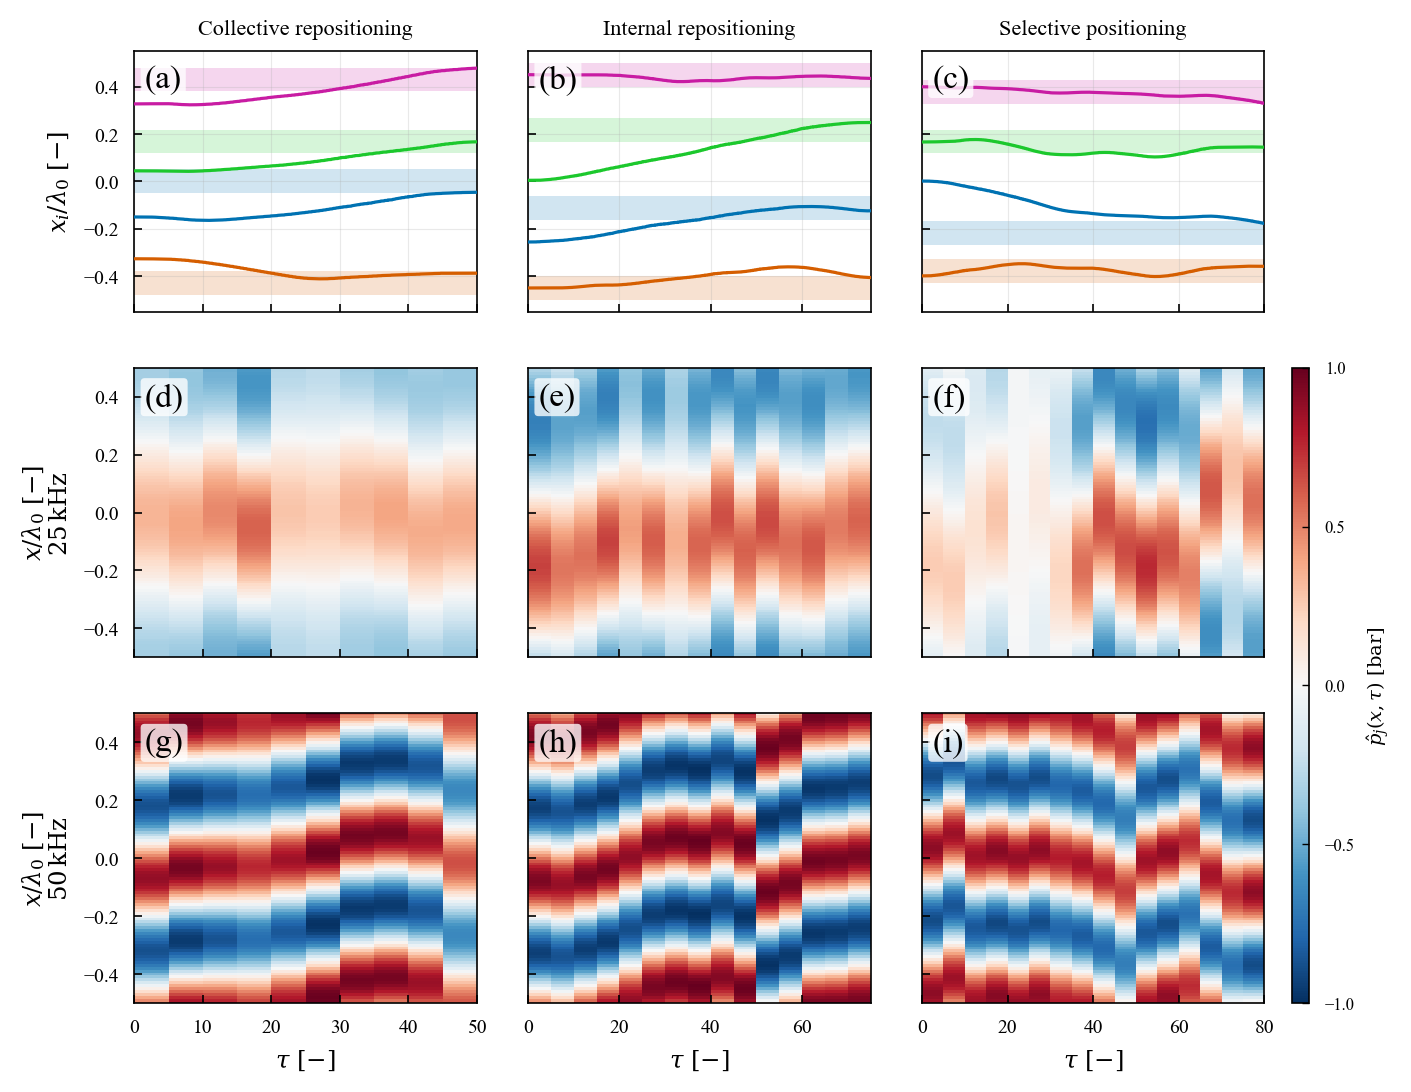

In [117]:

EPISODES = [4003, 6005, 6019]
UPS = 4
TOL = 5e-2

ACTION_DT = 5.0
PLOT_RES = 101
FIELD_VMAX = 1.0

xgrid = np.linspace(-0.5, 0.5, PLOT_RES)

dx = xgrid[1] - xgrid[0]
x_edges = np.r_[
    xgrid[0] - 0.5 * dx,
    0.5 * (xgrid[:-1] + xgrid[1:]),
    xgrid[-1] + 0.5 * dx,
]

field_norm = TwoSlopeNorm(vmin=-FIELD_VMAX, vcenter=0.0, vmax=FIELD_VMAX)

nrows, ncols = 3, len(EPISODES)

(fig_w, fig_h), adj = pu.two_column_figsize(
    nrows, ncols,
    width_in=7.0,
    panel_height_in=1.40,
    wspace=0.15,
    hspace=0.20,
)

# Hely a jobb oldali colorbarnak
adj["right"] = 0.90

with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        gridspec_kw={"height_ratios": [0.9, 1.0, 1.0]},
    )

    for j, episode in enumerate(EPISODES):
        trj = load_episode(TRAJECTORIES, episode)

        dense_time = np.asarray(trj["dense_time"])
        dense_state = trj["dense_state"]
        actions = np.asarray(trj["actions"])

        x = np.asarray(dense_state[1])
        target = np.asarray(trj["observations"][0, :UPS]) * 0.5

        # =========================================================
        # Top row: trajectories and target intervals
        # =========================================================

        for unit_id in range(UPS):
            color = pu.COLORS[unit_id]

            axes[0, j].axhspan(
                target[unit_id] - TOL,
                target[unit_id] + TOL,
                color=color,
                alpha=0.18,
                linewidth=0,
                zorder=0,
            )

            axes[0, j].plot(
                dense_time,
                x[:, unit_id],
                color=color,
                **pu.GPU_STYLE,
            )

        axes[0, j].set_ylim(-0.55, 0.55)
        axes[0, j].grid(True, which="major", linewidth=0.4, alpha=0.28, zorder=0)

        if j == 0:
            axes[0, j].set_ylabel(r"$x_i/\lambda_0\ [-]$")

        # =========================================================
        # Piecewise-constant action intervals
        # actions = [PA_0, PA_1, PS_0, PS_1]
        # =========================================================

        episode_duration = dense_time[-1] - dense_time[0]
        n_actions = min(len(actions), int(np.ceil(episode_duration / ACTION_DT)))
        actions = actions[:n_actions]

        action_edges = dense_time[0] + ACTION_DT * np.arange(n_actions + 1)
        action_edges[-1] = min(action_edges[-1], dense_time[-1])

        pa0 = actions[:, 0]
        pa1 = actions[:, 1]
        ps0 = actions[:, 2] * np.pi
        ps1 = actions[:, 3] * np.pi

        # =========================================================
        # Middle row: signed 25 kHz spatial amplitude
        # =========================================================

        field_0 = pa0[None, :] * np.sin(
            2.0 * np.pi * xgrid[:, None] + ps0[None, :]
        )

        axes[1, j].pcolormesh(
            action_edges,
            x_edges,
            field_0,
            shading="flat",
            cmap="RdBu_r",
            norm=field_norm,
            rasterized=True,
        )

        axes[1, j].set_ylim(-0.5, 0.5)

        if j == 0:
            axes[1, j].set_ylabel(
                r"$x/\lambda_0\ [-]$" "\n"
                r"$25\,\mathrm{kHz}$"
            )

        # =========================================================
        # Bottom row: signed 50 kHz spatial amplitude
        # =========================================================

        field_1 = pa1[None, :] * np.sin(
            4.0 * np.pi * xgrid[:, None] + ps1[None, :]
        )

        mesh = axes[2, j].pcolormesh(
            action_edges,
            x_edges,
            field_1,
            shading="flat",
            cmap="RdBu_r",
            norm=field_norm,
            rasterized=True,
        )

        axes[2, j].set_ylim(-0.5, 0.5)
        axes[2, j].set_xlim(dense_time[0], dense_time[-1])
        axes[2, j].set_xlabel(r"$\tau\ [-]$")

        if j == 0:
            axes[2, j].set_ylabel(
                r"$x/\lambda_0\ [-]$" "\n"
                r"$50\,\mathrm{kHz}$"
            )

        # =========================================================
        # Common axis formatting and panel labels
        # =========================================================

        for i in range(nrows):
            ax = axes[i, j]

            ax.tick_params(
                axis="both",
                which="major",
                direction="in",
                length=3,
                width=0.6,
                labelsize=7,
            )

            panel_label = chr(97 + i * ncols + j)

            ax.text(
                0.03,
                0.95,
                f"({panel_label})",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=12,
                bbox=dict(
                    boxstyle="round,pad=0.12",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.78,
                ),
                zorder=5,
            )

        column_titles = [
            "Collective repositioning",
            "Internal repositioning",
            "Selective positioning",
        ]

        for j, title in enumerate(column_titles):
            axes[0, j].set_title(title, fontsize=8, pad=6)

    fig.subplots_adjust(**adj)

    # =============================================================
    # Shared vertical colorbar for both acoustic components
    # =============================================================

    cbar_bottom = axes[2, 0].get_position().y0
    cbar_top = axes[1, 0].get_position().y1

    cax = fig.add_axes([0.92, cbar_bottom, 0.012, cbar_top - cbar_bottom])  # type: ignore
    cbar = fig.colorbar(mesh, cax=cax, orientation="vertical", ticks=[-1.0, -0.5, 0.0, 0.5, 1.0])

    cbar.set_label(r"$\hat{p}_j(x,\tau)\ [\mathrm{bar}]$", fontsize=7, labelpad=4)
    cbar.ax.tick_params(direction="in", length=2.5, width=0.5, labelsize=6)

fig.savefig("figs/bubble_4_control.pdf", bbox_inches="tight")
fig.savefig("figs/bubble_4_control.png", dpi=300, bbox_inches="tight")
plt.show()